# Notebook 1 - Exploratory Data Analysis (EDA)

**Project:** Predictive Maintenance

**What this notebook does:**
- Loads and inspects the dataset
- Checks for missing values and class imbalance
- Visualizes sensor data to find patterns

## Step 1 - Import Libraries
These are the tools we use throughout the project.

In [19]:
import pandas as pd          # load/work with data (like Excel in Python)
import numpy as np             # math on arrays
import matplotlib.pyplot as plt  # create charts
import seaborn as sns          # nicer charts

## Step 2 - Load and Inspect the Dataset
We load the CSV into a DataFrame (Python's version of a spreadsheet).

In [20]:
df=pd.read_csv('/Users/priyankakadam/Desktop/Projects/Predictive Maintenance/ai4i2020.csv')
print('Shape:',df.shape) # (rows, columns)

df.head() # show first 5 rows

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [21]:
# Check column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [22]:
# Check for missing values 
missing = df.isnull().sum()
if missing.sum() == 0:
    print('No missing values - dataset is clean!')
else:
    print(missing[missing > 0])

No missing values - dataset is clean!


## Step 3 - Understand the Columns

| Column | What it means |
|--------|---------------|
| `UDI` | Just a row number - drop it |
| `Product ID` | Machine serial number - drop it |
| `Type` | Machine quality: L / M / H |
| `Air temperature [K]` | Air temp in Kelvin (~300K = 27 degrees C) |
| `Process temperature [K]` | Machine internal temp |
| `Rotational speed [rpm]` | How fast the machine spins |
| `Torque [Nm]` | Force applied to the machine |
| `Tool wear [min]` | Minutes the tool has been running |
| `Machine failure` | **Our TARGET: 0 = healthy, 1 = failure** |
| TWF, HDF, PWF, OSF, RNF | Failure sub-types - we will drop these |


## Step 4 - Check Class Imbalance
Only ~3.4% of machines fail. 

In [23]:
print('Failure distribution:')
print(df['Machine failure'].value_counts())
print()
print('As percentages:')
print((df['Machine failure'].value_counts(normalize=True) * 100).round(2))

Failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

As percentages:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


/var/folders/4f/ftthg2hd3078vc_c96ylnyc40000gp/T/ipykernel_3882/3849660102.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df, palette=['#4f8ef7', '#f74f7a'], ax=axes[0])
/var/folders/4f/ftthg2hd3078vc_c96ylnyc40000gp/T/ipykernel_3882/3849660102.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Failure (0)', 'Failure (1)'])


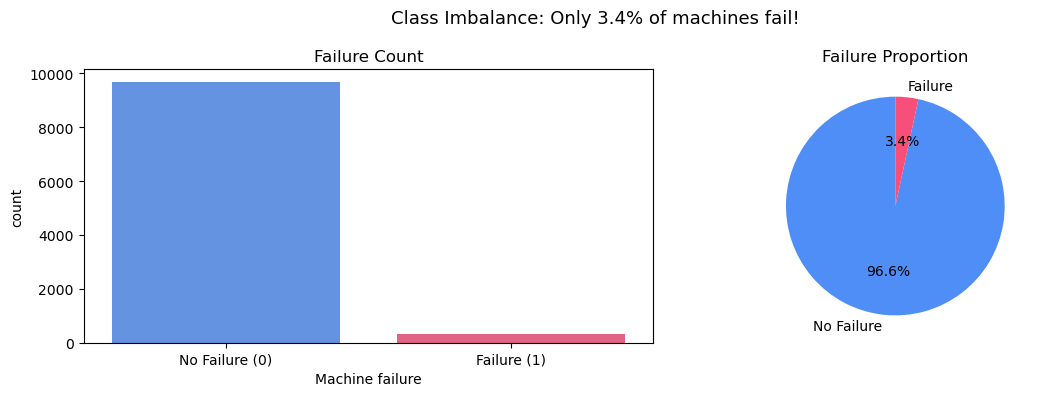

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Machine failure', data=df, palette=['#4f8ef7', '#f74f7a'], ax=axes[0])
axes[0].set_title('Failure Count')
axes[0].set_xticklabels(['No Failure (0)', 'Failure (1)'])

# Pie chart
counts = df['Machine failure'].value_counts()
axes[1].pie(counts, labels=['No Failure', 'Failure'],
            colors=['#4f8ef7', '#f74f7a'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Failure Proportion')

plt.suptitle('Class Imbalance: Only 3.4% of machines fail!', fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 - Explore Sensor Distributions
Do failed machines read differently from healthy ones?
If red and blue bars look different -> that sensor is useful for prediction!

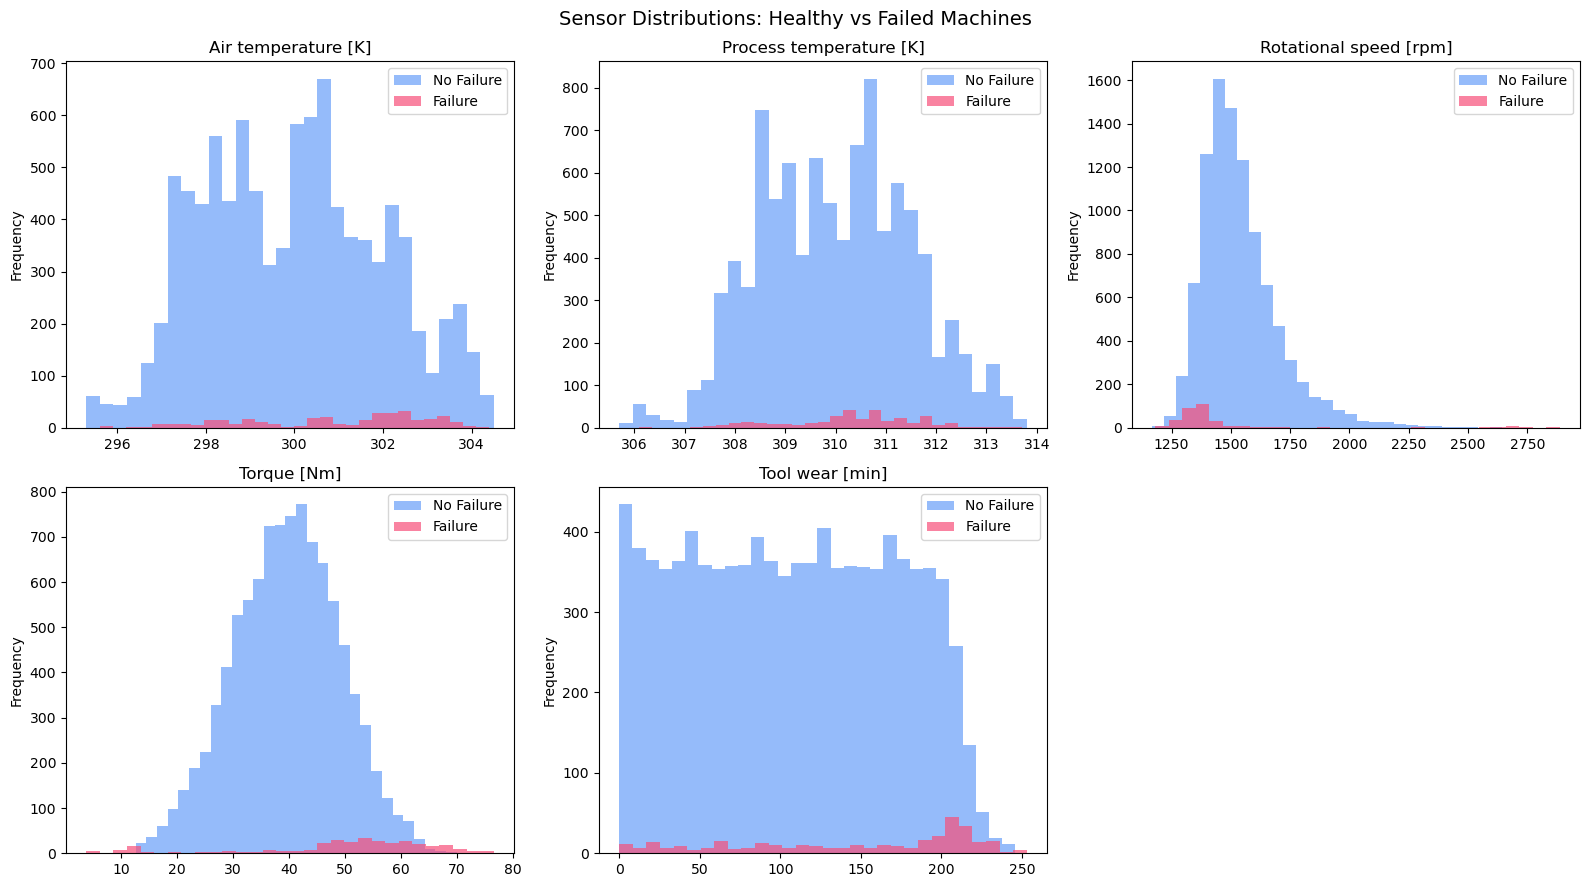

TIP: Where red and blue do NOT overlap -> that sensor predicts failure well!


In [25]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    df[df['Machine failure'] == 0][col].plot(
        kind='hist', ax=axes[i], alpha=0.6, color='#4f8ef7', label='No Failure', bins=30)
    df[df['Machine failure'] == 1][col].plot(
        kind='hist', ax=axes[i], alpha=0.7, color='#f74f7a', label='Failure', bins=30)
    axes[i].set_title(col)
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Sensor Distributions: Healthy vs Failed Machines', fontsize=14)
plt.tight_layout()
plt.show()
print('TIP: Where red and blue do NOT overlap -> that sensor predicts failure well!')

## Step 6 - Correlation Heatmap
Correlation tells us: as X goes up, does failure go up too?
We want features with high (or low) correlation to 'Machine failure'.

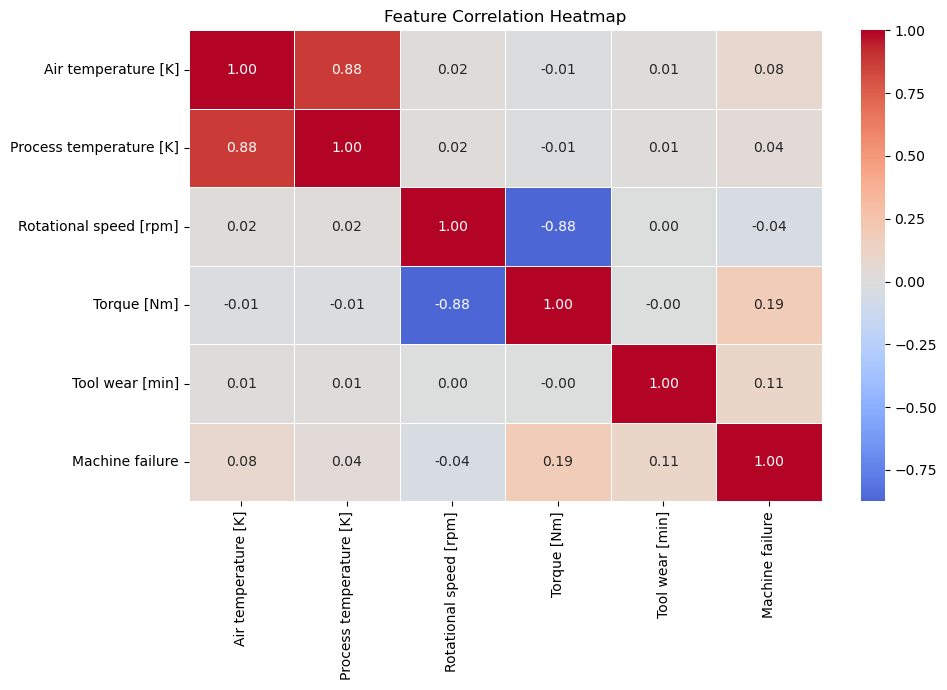

Correlation with Machine failure (sorted):
Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188


In [26]:
cols_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_numeric = df.drop(columns=cols_to_drop, errors='ignore').select_dtypes(include='number')

plt.figure(figsize=(10, 7))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print('Correlation with Machine failure (sorted):')
print(df_numeric.corr()['Machine failure'].sort_values(ascending=False).to_string())

## Step 7 - Failure Rate by Machine Type
Does quality type (L/M/H) affect how often a machine fails?

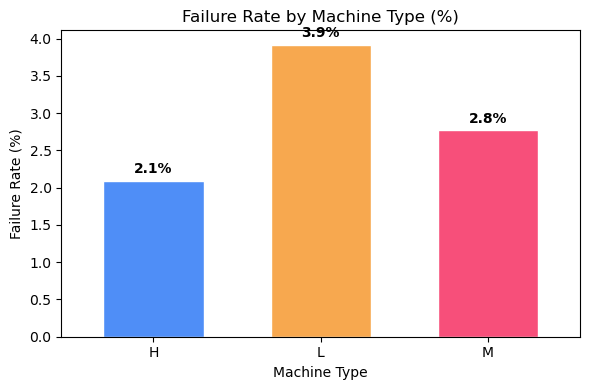

In [27]:
failure_by_type = df.groupby('Type')['Machine failure'].mean() * 100

plt.figure(figsize=(6, 4))
failure_by_type.plot(kind='bar', color=['#4f8ef7', '#f7a84f', '#f74f7a'], edgecolor='white', width=0.6)
plt.title('Failure Rate by Machine Type (%)')
plt.ylabel('Failure Rate (%)')
plt.xlabel('Machine Type')
plt.xticks(rotation=0)
for i, v in enumerate(failure_by_type):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## EDA Summary

**Key findings:**
- 10,000 rows, no missing values
- Only **3.4% failure rate** -> class imbalance (we fix this in Notebook 2 with SMOTE)
- **Tool wear** and **Torque** have the strongest correlation with failure
- **Machine Type L** has the highest failure rate